In [106]:
import numpy as np
from colossus.cosmology import cosmology
cosmology.setCosmology('planck15') 
from colossus.lss import mass_function as mf 
import glob
import numexpr as ne
import sys
from scipy.optimize import newton


files = [f.split('a')[1].split('.d')[0] for f in glob.glob('ssfrs/ssfr_a*.dat')]
a_list = np.array([float(a) for a in files])
mass_list = np.array([np.loadtxt("ssfrs/ssfr_a"+f+".dat")[:,0] for f in files])
ssfr_list = [np.loadtxt("ssfrs/ssfr_a"+f+".dat")[:,1] for f in files]
    
param_file = np.loadtxt("smhm_params.txt")
names = "EFF_0 EFF_0_A EFF_0_A2 EFF_0_Z M_1 M_1_A M_1_A2 M_1_Z ALPHA ALPHA_A ALPHA_A2 ALPHA_Z BETA BETA_A BETA_Z DELTA GAMMA GAMMA_A GAMMA_Z CHI2".split(" ");
params = dict(zip(names, param_file[:,1]))

def create_ranges_numexpr(start, stop, N):

    divisor = N-1
    s0 = start[:,None]
    s1 = stop[:,None]
    r = np.arange(N)

    return ne.evaluate('((1.0/divisor) * (s1 - s0))*r + s0')

def grab_obs(redshift):
    
    obs_points = []
    with open("obs_collect.dat", 'r') as f:
        for line in f:
            if line[0:4] != ';;//':
                obs_points.append(line.split())
    x = []
    y = []
    yerr = []
    for i in obs_points:
        if float(i[0]) == redshift:
            x.append(float(i[1]))
            y.append(float(i[2]))
            yerr.append(float(i[3]))
            
    return(x,y,yerr)



class QLF():
    def __init__(self, z, bin_num):
        
        
        self.z = float(z)
        self.a = 1.0/(1.0+self.z)
        self.bin_num = bin_num
        self.get_zparams()
        
        self.max_halo = 15.
        self.HaloBins = np.linspace(7., self.max_halo, bin_num)
        slopes = self.get_slope(self.HaloBins)
        while slopes[-1] < 0:
            self.max_halo -= .1
            self.HaloBins = np.linspace(7., self.max_halo, bin_num)
            slopes = self.get_slope(self.HaloBins)
            
        self.max_stell = self.get_Mstar(self.max_halo)
        
        self.fp = self.HaloBins
        self.xp = self.get_Mstar(self.fp)
        
        self.LumBins = np.linspace(5., 16., bin_num)
        self.StellBins = np.linspace(5.,self.max_stell, bin_num)
        
        
    def get_zparams(self):
        a1 = self.a - 1.0
        lna = np.log(self.a)
        self.zparams = {}
        self.zparams['m_1'] = params['M_1'] + a1*params['M_1_A'] - lna*params['M_1_A2'] + self.z*params['M_1_Z']
        self.zparams['sm_0'] = self.zparams['m_1'] + params['EFF_0'] + a1*params['EFF_0_A'] - lna*params['EFF_0_A2'] + self.z*params['EFF_0_Z']
        self.zparams['alpha'] = params['ALPHA'] + a1*params['ALPHA_A'] - lna*params['ALPHA_A2'] + self.z*params['ALPHA_Z']
        self.zparams['beta'] = params['BETA'] + a1*params['BETA_A'] + self.z*params['BETA_Z']
        self.zparams['delta'] = params['DELTA']
        self.zparams['gamma'] = 10**(params['GAMMA'] + a1*params['GAMMA_A'] + self.z*params['GAMMA_Z'])
        
    
    def get_slope(self, Mhalo):

        dm = Mhalo-self.zparams['m_1'];
        term1 = (self.zparams['alpha']*10.**(self.zparams['beta']*dm)+self.zparams['beta']*10.**(self.zparams['alpha']*dm))/(10.**(self.zparams['beta']*dm) + 10.**(self.zparams['alpha']*dm))
        term2 = -self.zparams['gamma']*dm*np.exp(-(dm/self.zparams['delta'])**2/2.)/self.zparams['delta']**2
        slope = term1 + term2

        return slope
    
    def get_Mstar(self, Mhalo):
    
        dm = Mhalo-self.zparams['m_1']
        dm2 = dm/self.zparams['delta']
        Mstar = self.zparams['sm_0'] - np.log10(10**(-self.zparams['alpha']*dm) + 10**(-self.zparams['beta']*dm)) + self.zparams['gamma']*np.exp(-0.5*(dm2*dm2))

        return Mstar
    
    
    def get_Mhalo(self, Mstar):
        
        Mhalo = np.interp(Mstar, self.xp, self.fp)
        
        return Mhalo
    
    
    def get_SMBM(self, dM, Mmid, slope1 = 0.2, slope3 = 1.):

        start = [7., np.log10(1.4*10**4.)]
        stop = [12., np.log10(1.4*10**9.)]
        mstar1 = Mmid - dM
        mstar2 = Mmid + dM
        int1 = start[1] - start[0] * slope1
        int3 = stop[1] - stop[0] * slope3
        x = (int3 - int1) / (slope1 - slope3)
        y = slope1 * x + int1
        if mstar1 < x:
            mstar1 = x
        mbh1 = slope1 * mstar1 + int1
        mbh2 = mstar2 + int3
        slope2 = (mbh2 - mbh1) / (mstar2 - mstar1)
        int2 = mbh2 - mstar2 * slope2

        self.slope_list, self.int_list, self.mass_cuts = [slope1, slope2, slope3], [int1, int2, int3], [mstar1, mstar2] 
    
    
    def gauss_array(self, vals, std, amp):

        y = (amp/np.sqrt(2.0*np.pi*std**2.0))*np.exp((-(vals[-1]-vals[:-1])**2.0)/(2.0*std**2))

        return y

    
    def convolve_smhm(self, StellBins, sigma, bin_num, z): 

        halomasses = self.get_Mhalo(np.asarray(StellBins))
        plus_mins = (5.0 * sigma) / self.get_slope(np.asarray(halomasses))
        mins = halomasses - plus_mins
        maxs = halomasses + plus_mins
        mins[mins < 7.] = 7.
        maxs[maxs > self.max_halo] = self.max_halo
        MHalo = create_ranges_numexpr(mins, maxs, bin_num)
        dNdMhalo = mf.massFunction(10.**MHalo, z, q_in='M', q_out='dndlnM', mdef='vir', model='despali16') * np.log(10)
        meanMstar = np.apply_along_axis(self.get_Mstar, 1, MHalo)
        values = np.zeros((bin_num,bin_num+1))
        values[:,-1] = StellBins
        values[:,:-1] = meanMstar
        Mstar_prob = np.apply_along_axis(self.gauss_array, 1, values, sigma, 1)
        dNdMstar = np.sum(Mstar_prob * dNdMhalo, axis = 1) * (MHalo[:,1] - MHalo[:,0])

        return dNdMstar
    
    
    
    def get_dNdMstar(self, smhm_scat):
        
        if smhm_scat == 0.:
            self.dNdMstar = mf.massFunction(10.**self.get_Mhalo(self.StellBins), self.z, q_in='M', q_out='dndlnM', mdef='vir', model='despali16')  / (get_slope(um.get_Mhalo(self.StellBins, self.z)) * np.log10(np.e))
        else:
            self.dNdMstar = self.convolve_smhm(self.StellBins, smhm_scat, self.bin_num, self.z)


            
    def get_dNdMbh(self):
        
        self.early = (self.StellBins <= self.mass_cuts[0])
        self.growth = ((self.StellBins > self.mass_cuts[0]) & (self.StellBins < self.mass_cuts[1]))
        self.late = (self.StellBins > self.mass_cuts[1])
        self.m = np.zeros(len(self.StellBins))
        self.m[self.early] = self.slope_list[0]
        self.m[self.growth] = self.slope_list[1]
        self.m[self.late] = self.slope_list[2]
        self.dNdMbh = self.dNdMstar / self.m
        
        
    def etas(self, Mbh):
    
        n = np.asarray(self.LumBins) - np.log10(3.3e4) - Mbh

        return n
        
        
        
            
    def get_mean_etas(self, vals, a, xsigs, files = files):

        Mbh = vals[0]
        Mstar = vals[1]
        slope = vals[2]
        if slope == self.slope_list[0]:
            xsig = xsigs[0]
        else:
            xsig = xsigs[1]
        closest_a = np.argmin(np.abs(a_list - a))
        closest_m = np.argmin(np.abs(mass_list[closest_a] - Mstar))
        ssfr = ssfr_list[closest_a][closest_m]

        Ledd = 1.3*10**31 * 10**Mbh #J/s 
        Mdotedd = Ledd / (.1 * (2.99*10**8)**2) #kg/s???
        sbhr = slope*(ssfr/(3.154*10**7)) #1/s??
        eta = sbhr*(10**Mbh*2*10**30/Mdotedd)
        nsig = 10**xsig * eta
        
        return np.log10(eta), np.abs(np.log10(nsig))
    
    def gauss(self, x, *var):
  
        mean, std, amp = var
        y = (amp/np.sqrt(2.0*np.pi*std**2.0))*np.exp((-(x-mean)**2.0)/(2.0*std**2))

        return y
    
    
    def prob_eddratios(self, vals, obscured):

        amp = 1 - obscured
        probdens = self.gauss(vals[:-2], vals[-2]-(vals[-1]**2)/2, vals[-1], amp)

        return probdens
    
    def get_dNdL(self, xsigs, obscured):
        
        ###exp sig growth
            
        b = np.zeros(self.bin_num)
        b[self.early] = self.int_list[0]
        b[self.growth] = self.int_list[1]
        b[self.late] = self.int_list[2]

        leftc = np.argmin(self.early)
        rightc = np.argmax(self.late)
        per = len(self.growth[self.growth==True])*.1
        cut1l = int(leftc - per)
        cut1r = int(leftc + per + 1)
        cut2l = int(rightc - per)
        cut2r = int(rightc + per + 1)

        BHBins = self.StellBins * self.m + b
        eta_lists = np.apply_along_axis(self.etas, 1, np.reshape(BHBins,(self.bin_num,1)))

        vals = np.zeros((self.bin_num,3))
        vals[:,0] = BHBins
        vals[:,1] = self.StellBins
        vals[:,2] = self.m
        mean_etas = np.apply_along_axis(self.get_mean_etas, 1, vals, self.a, xsigs)
        print(mean_etas[:,1])
        
        vals = np.zeros((self.bin_num, self.bin_num+2))
        vals[:,:-2] = eta_lists
        vals[:,-2] = mean_etas[:,0]
        vals[:,-1] = mean_etas[:,1]
        
        self.dNdL = np.log10(np.sum(np.apply_along_axis(self.prob_eddratios, 1, vals, obscured) * np.reshape(self.dNdMbh,(self.bin_num,1)) * (self.StellBins[1] - self.StellBins[0]) * np.reshape(self.m,(self.bin_num,1)), axis = 0))
        ind_dNdL_off = np.apply_along_axis(self.prob_eddratios, 1, vals, obscured) * np.reshape(self.dNdMbh,(self.bin_num,1)) * (self.StellBins[1] - self.StellBins[0]) * np.reshape(self.m,(self.bin_num,1))
        self.ind_dNdL = np.zeros((self.bin_num,self.bin_num))
        c = 0
        for l in ind_dNdL_off:
            self.ind_dNdL[c,:] = l
            c += 1
        

[1.31466317 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317
 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317
 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317
 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317
 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317
 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317
 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317
 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317
 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317
 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317
 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317
 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317
 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317
 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317
 1.31466317 1.31466317 1.31466317 1.31466317 1.31466317 1.3146

/Users/megantillman/anaconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:19: RuntimeWarning: divide by zero encountered in log10


[]

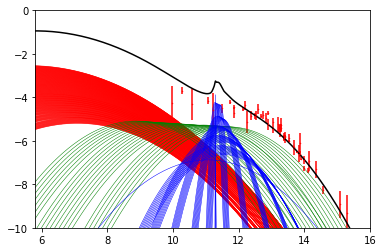

In [107]:
import matplotlib.pyplot as plt
bins = 300
z = 2.5
obscured = .75
qlf = QLF(z, bins)
qlf.get_dNdMstar(0.3)
qlf.get_SMBM(.25, 10.3)
qlf.get_dNdMbh()
qlf.get_dNdL([.45,.95], obscured)
xm, ym = qlf.LumBins, qlf.dNdL
plt.plot(xm,ym,c='k')
ym_in = qlf.ind_dNdL
col = np.zeros(qlf.bin_num)
col[qlf.early] = 0
col[qlf.growth] = 1
col[qlf.late] = 2
for l, c in zip(ym_in, col):
    c_list = ['r','g','b']
    plt.plot(xm, np.log10(l), linewidth = .5, color = c_list[int(c)])
plt.axis([5.8,16,-10,0])
x, y , yerr = grab_obs(z)
plt.errorbar(x, y, yerr = yerr, fmt = 'o', markersize = .5,color='r')
plt.plot()